* Scatter plots are used to observe relationships between variables. The scatter() method in the matplotlib library is used to draw a scatter plot.


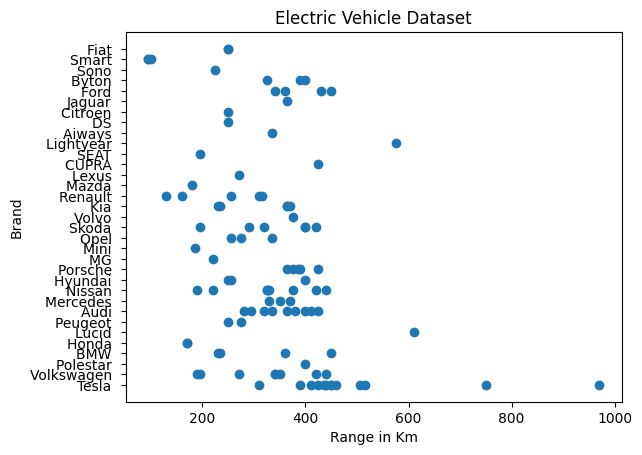

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ElectricVehicleData.csv')
x = data['Range_Km']
y = data['Brand']

plt.scatter(x, y)

plt.title("Electric Vehicle Dataset")

plt.ylabel('Brand')

plt.xlabel('Range in Km')

plt.show()

In [3]:
data.columns

Index(['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH', 'Range_Km',
       'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge', 'PowerTrain',
       'PlugType', 'BodyStyle', 'Segment', 'Seats', 'PriceEuro'],
      dtype='object')

In [4]:
data.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480
1,Volkswagen,ID.3 Pure,10.0,160,270,167,250,Yes,RWD,Type 2 CCS,Hatchback,C,5,30000
2,Polestar,2,4.7,210,400,181,620,Yes,AWD,Type 2 CCS,Liftback,D,5,56440
3,BMW,iX3,6.8,180,360,206,560,Yes,RWD,Type 2 CCS,SUV,D,5,68040
4,Honda,e,9.5,145,170,168,190,Yes,RWD,Type 2 CCS,Hatchback,B,4,32997


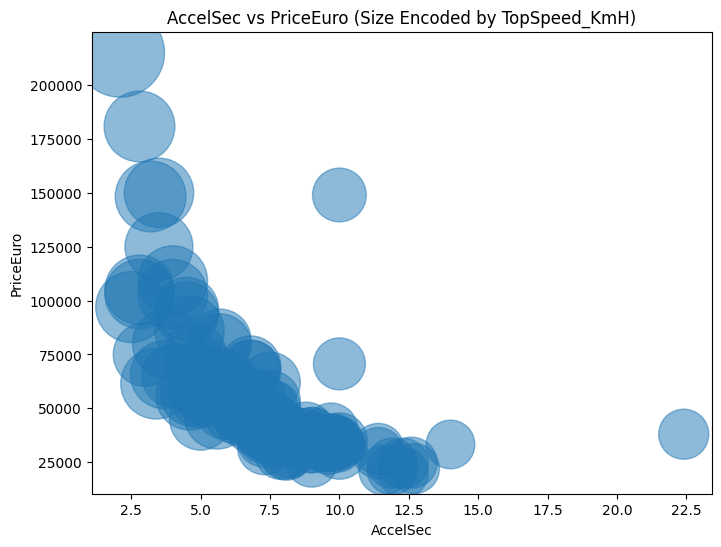

In [5]:
# 2. Size-Encoded Scatter Plot 
sizes = data['TopSpeed_KmH'] * 10  # Scale for better visibility
plt.figure(figsize=(8, 6))
plt.scatter(data['AccelSec'], data['PriceEuro'], s=sizes, alpha=0.5)
plt.title("AccelSec vs PriceEuro (Size Encoded by TopSpeed_KmH)")
plt.xlabel('AccelSec')
plt.ylabel('PriceEuro')
plt.show()

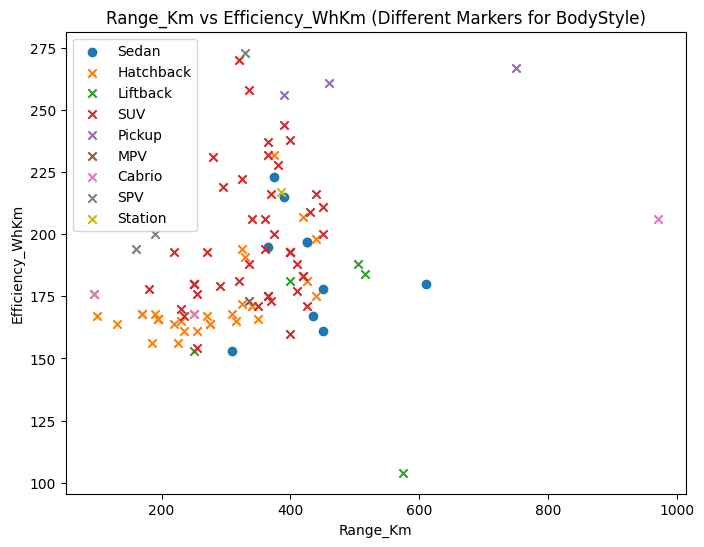

In [6]:
# 3. **Scatter Plot with Different Markers**
plt.figure(figsize=(8, 6))
for body_style in data['BodyStyle'].unique():
    subset = data[data['BodyStyle'] == body_style]
    plt.scatter(subset['Range_Km'], subset['Efficiency_WhKm'], label=body_style, marker='o' if body_style == 'Sedan' else 'x')
plt.title("Range_Km vs Efficiency_WhKm (Different Markers for BodyStyle)")
plt.xlabel('Range_Km')
plt.ylabel('Efficiency_WhKm')
plt.legend()
plt.show()

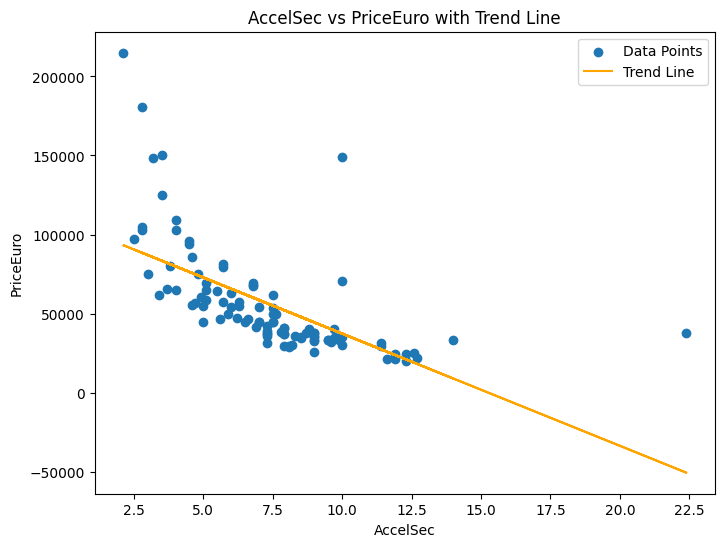

In [7]:
# 4. **Scatter Plot with Trend Line**

import numpy as np
m, b = np.polyfit(data['AccelSec'], data['PriceEuro'], 1)
trend_line = m * data['AccelSec'] + b
plt.figure(figsize=(8, 6))
plt.scatter(data['AccelSec'], data['PriceEuro'], label='Data Points')
plt.plot(data['AccelSec'], trend_line, color='orange', label='Trend Line')
plt.title("AccelSec vs PriceEuro with Trend Line")
plt.xlabel('AccelSec')
plt.ylabel('PriceEuro')
plt.legend()
plt.show()


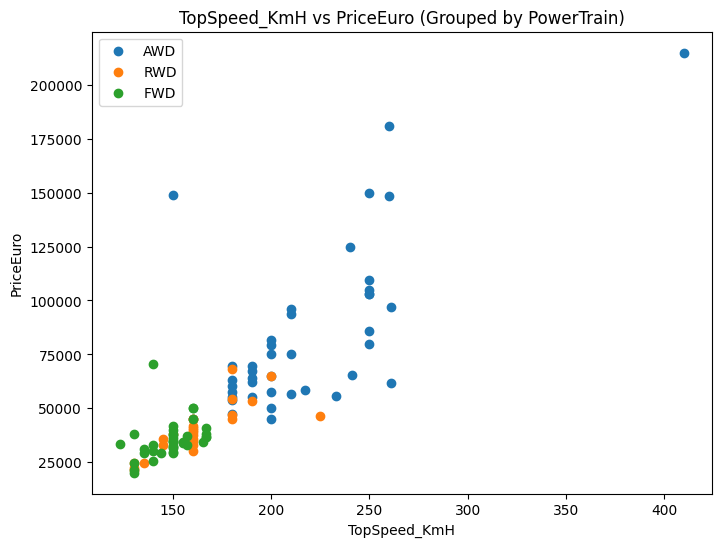

In [8]:
# 5.Grouped Scatter Plot
plt.figure(figsize=(8, 6))
for powertrain in data['PowerTrain'].unique():
    subset = data[data['PowerTrain'] == powertrain]
    plt.scatter(subset['TopSpeed_KmH'], subset['PriceEuro'], label=powertrain)
plt.title("TopSpeed_KmH vs PriceEuro (Grouped by PowerTrain)")
plt.xlabel('TopSpeed_KmH')
plt.ylabel('PriceEuro')
plt.legend()
plt.show()


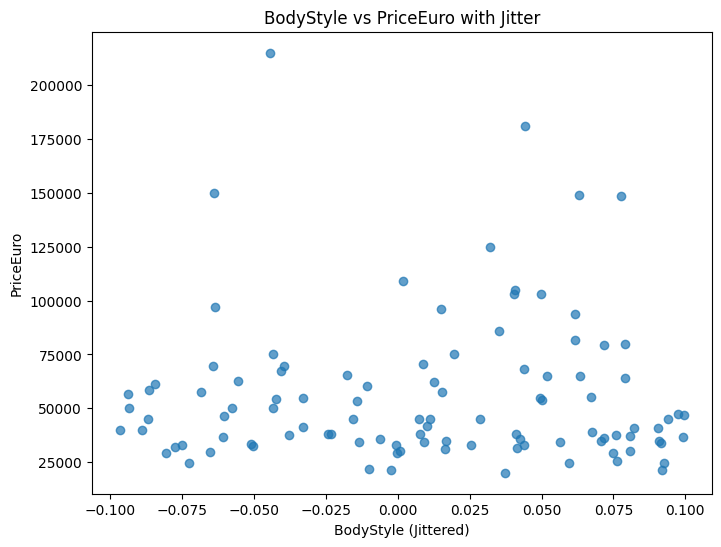

In [9]:
# 6. **Scatter Plot with Jitter**
import random
jittered_body_style = data['BodyStyle'].apply(lambda x: random.uniform(-0.1, 0.1))
plt.figure(figsize=(8, 6))
plt.scatter(jittered_body_style, data['PriceEuro'], alpha=0.7)
plt.title("BodyStyle vs PriceEuro with Jitter")
plt.xlabel('BodyStyle (Jittered)')
plt.ylabel('PriceEuro')
plt.show()

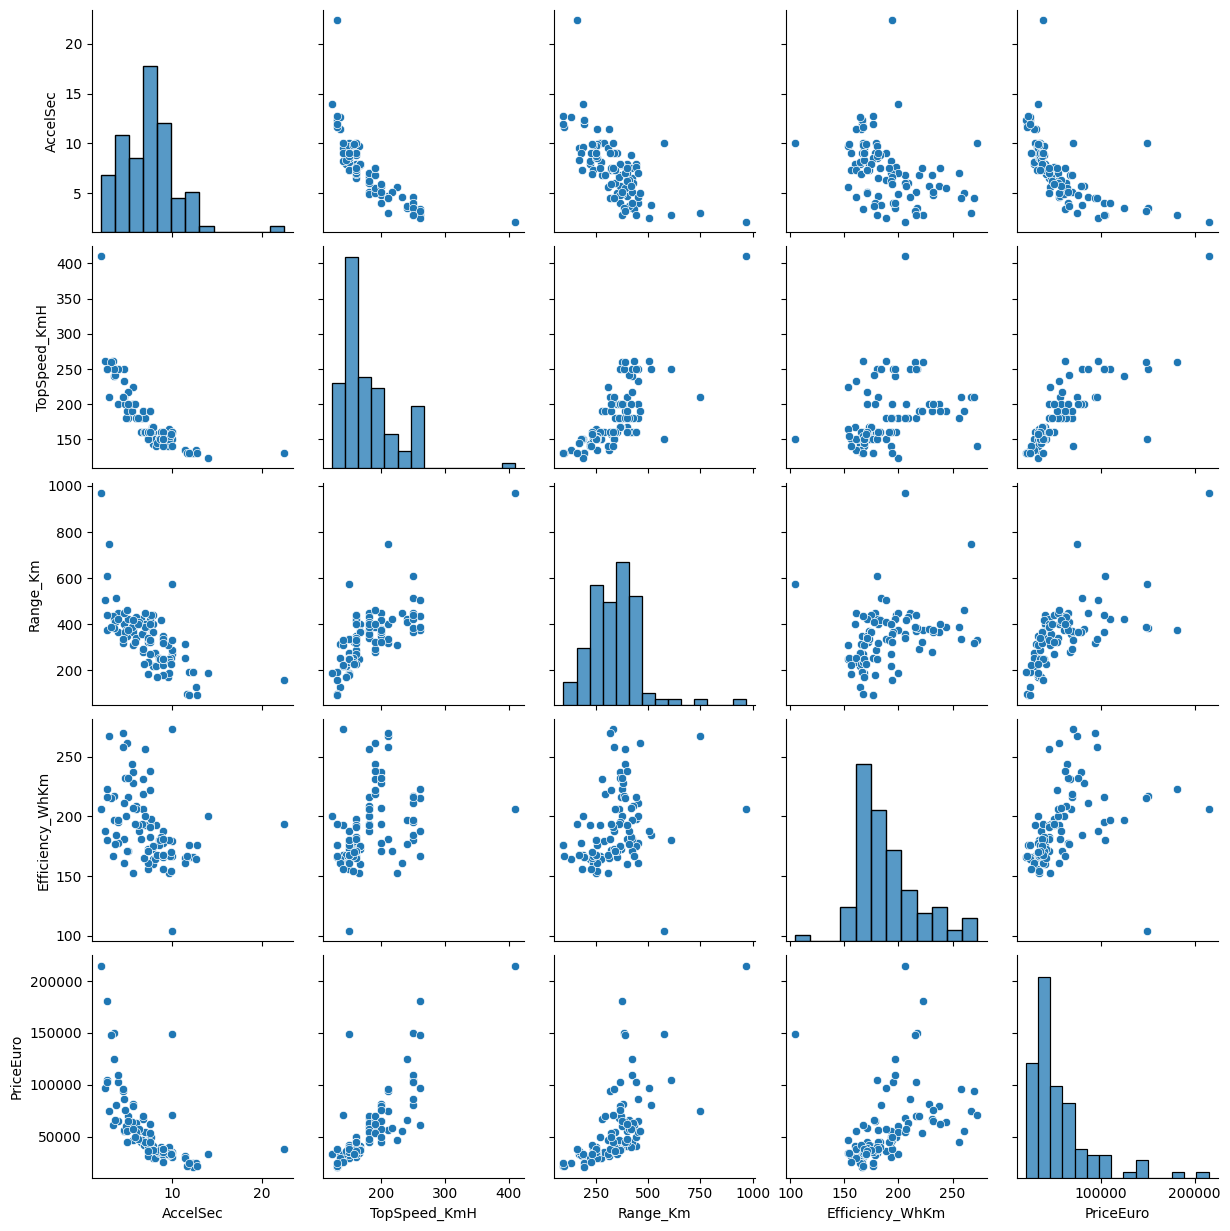

In [10]:
# 7.**Scatter Plot Matrix**
import seaborn as sns
sns.pairplot(data[['AccelSec', 'TopSpeed_KmH', 'Range_Km', 'Efficiency_WhKm', 'PriceEuro']])
plt.show()

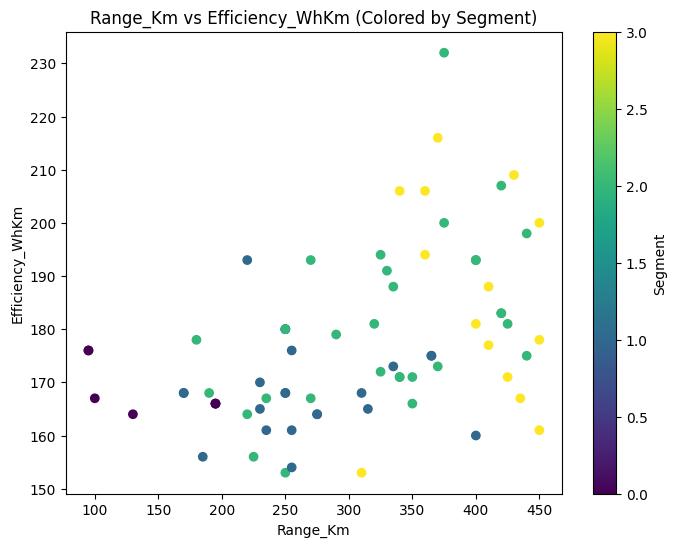

In [11]:
# 8. **Color-Coded Scatter Plot**
plt.figure(figsize=(8, 6))

# Create a colormap based on the 'Segment' column
segments = {'A': 0, 'B': 1, 'C': 2, 'D': 3}  # Map segment labels to numbers
data['SegmentNum'] = data['Segment'].map(segments)

# Scatter plot with colormap
scatter = plt.scatter(data['Range_Km'], data['Efficiency_WhKm'], c=data['SegmentNum'], cmap='viridis')

# Add a colorbar to show the mapping of colors to segments
plt.colorbar(scatter, label='Segment')

plt.title("Range_Km vs Efficiency_WhKm (Colored by Segment)")
plt.xlabel('Range_Km')
plt.ylabel('Efficiency_WhKm')
plt.show()